In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("train.csv")

print(df.head())

print(df.shape)
print(df.isnull().sum())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [5]:
X = df[["GrLivArea", "BedroomAbvGr", "FullBath"]]

y = df["SalePrice"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
y_pred = model.predict(X_test)

Mean Absolute Error: 35788.0612924363
Mean Squared Error: 2806426667.247853
Root Mean Squared Error: 52975.71771338122
R² Score: 0.6341189942328371


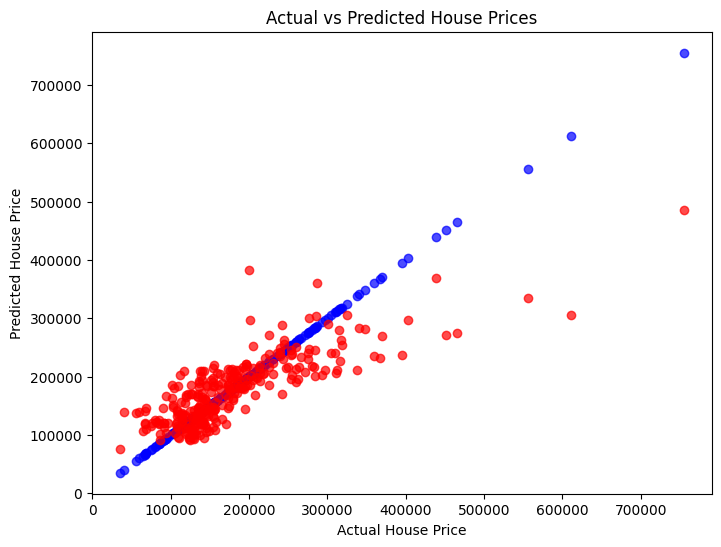

In [14]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R² Score:", r2)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test,
            color='blue',
            label='Actual Price',
            alpha=0.7)

plt.scatter(y_test, y_pred,
            color='red',
            label='Predicted Price',
            alpha=0.7)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()


In [10]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
892         154500    113410.672553
1105        325000    305081.877759
413         115000    135904.785630
522         159000    205424.675641
1036        315500    227502.683490
614          75500    121157.480796
218         311500    205577.980566
1160        146000    183787.203783
649          84500    121157.480796
887         135500    147219.222332


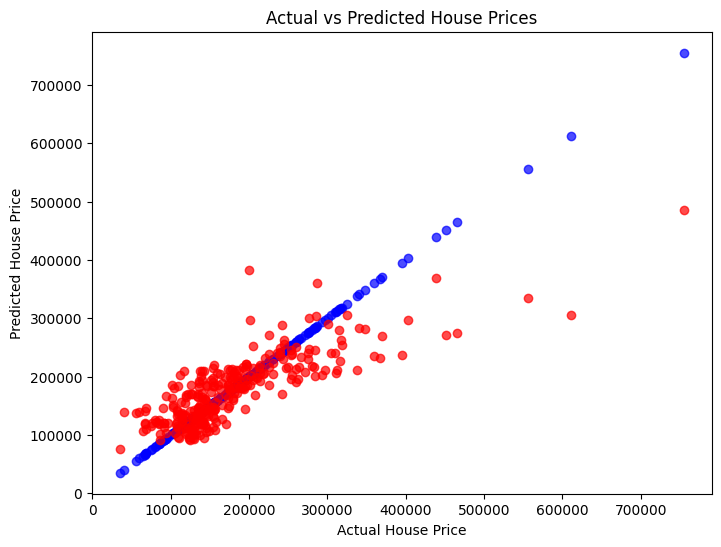

In [12]:
new_house = [[2000, 3, 2]]

predicted_price = model.predict(new_house)

print("Predicted House Price: $", predicted_price[0])

Predicted House Price: $ 240377.51479736285


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
